# Introduction

Score and Gene Expression vs Distance — Fig 6A/C/D/E & SuppFig 9A/B/C/E/D/F/G/H/I
Analyzes gene expression scores (Caushi, Type I/II IFN, MAPK) and IFNG expression
as a function of distance from CD8T or Epithelial cells (Xenium data).

In [1]:
fig.size <- function(h, w) {
    options(repr.plot.height = h, repr.plot.width = w)
}

library(dplyr)
library(tidyr)
library(purrr)
library(ggplot2)
library(ggthemes)
library(patchwork)
library(ggpubr)
devtools::document("/n/data1/bwh/medicine/korsunsky/lab/hoy821/git_pkg/singlecellmethods")
devtools::load_all("/n/data1/bwh/medicine/korsunsky/lab/hoy821/git_pkg/singlecellmethods")
library(lme4)
library(FNN)
library(rmcorr)

Warning message:
“package ‘dplyr’ was built under R version 4.1.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘tidyr’ was built under R version 4.1.3”
Warning message:
“package ‘purrr’ was built under R version 4.1.3”
ℹ Updating singlecellmethods documentation
Warning message:
“Installed roxygen2 is older than the version used with this package
ℹ You have "7.2.3" but you need "7.3.2"”
ℹ Loading singlecellmethods
Loading required package: data.table


Attaching package: ‘data.table’


The following object is masked from ‘package:purrr’:

    transpose


The following objects are masked from ‘package:dplyr’:

    between, first, last


Warning message:
“Skipping singlecellmethods.Rd
ℹ File lacks name and/or title”
ℹ Loading singlecellmethods
Warning message:
“package ‘lme4’ was built under R version 4.1.3”


# Read

In [ ]:
system.time({
# Need count matrix from it
    fdir <- file.path(".")
obj <- readRDS(file.path(fdir, "obj.RDS"))
})

   user  system elapsed 
 20.832   0.667  21.571 

In [ ]:
fdir <- file.path(".")


cell_meta <- readRDS(file.path(fdir, "cell_meta.rds"))
tile_meta <- readRDS(file.path(fdir, "tile_meta.rds"))
sample_meta <- readRDS(file.path(fdir, "sample_meta.rds"))
celltype_meta <- readRDS(file.path(fdir, "celltype_meta.rds"))

In [4]:
counts <- obj@assays$RNA@counts

Loading required package: SeuratObject

Loading required package: sp



# Annotate distance

Calulate nearest distance to specified cell type for every cell

In [5]:
compute_nn_dist <- function(
    df,
    target,
    celltype_col,
    sample_col="new_specimenID",
    x_col="x_mod",
    y_col="y_mod"
){
    df <- as.data.frame(df)
    out_df <- purrr::map(unique(df[[sample_col]]), function(.sample){
        sub_df <- df %>% 
            filter(.data[[sample_col]] == .sample)
        ref_df <- sub_df %>% 
            filter(.data[[celltype_col]] == target)
        sub_df[[paste0("dist_to_", target)]] <- knnx.dist(
            data=as.matrix(ref_df[, c(x_col, y_col)]),
            query=as.matrix(sub_df[, c(x_col, y_col)]), k=1)[, 1]
        return(sub_df)
    }) %>% 
    bind_rows()
    return(out_df)
}

In [6]:
cell_meta <- compute_nn_dist(
    df=cell_meta, target="CD8T", celltype_col="celltype_lvl_2")

In [7]:
cell_meta <- compute_nn_dist(
    df=cell_meta, target="Epithelial", celltype_col="celltype_level_1")

# Score

## Function

In [8]:
df_score_wilcox_test <- function(df, score, group_1 = "on", group_2 = "pre", group_var = "new_treatment"){
    vec_1 <- df %>% filter(.data[[group_var]] == group_1) %>% pull(.data[[score]])
    vec_2 <- df %>% filter(.data[[group_var]] == group_2) %>% pull(.data[[score]])
    if(length(vec_1) <= 1 | length(vec_2) <= 1) return(NA)
    test_res <- wilcox.test(vec_1, vec_2)
    res <- list(
        pvalue=test_res$p.value, mean_diff=mean(vec_1) - mean(vec_2),
        fc=mean(vec_1)/mean(vec_2))
    res
}

# make sure that the columns of counts_mat and the rows of meta_data are in the same order
pseudo_bulk <- function(counts_mat, meta_data, var_use){
    counts_mat <- counts_mat %*% sparse.model.matrix(~ 0 + meta_data[[var_use]])
    colnames(counts_mat) <- gsub("meta_data\\[\\[var_use\\]\\]", "", colnames(counts_mat))
    counts_mat
}

get_exp <- function(counts_mat, meta_data, var_use){
    counts_mat <- pseudo_bulk(counts_mat, meta_data, var_use)
    prop_mat <- counts_mat %*% diag(1 / colSums(counts_mat))
    colnames(prop_mat) <- colnames(counts_mat)
    norm_mat <- singlecellmethods::normalizeData(counts_mat, scaling_factor = 10^4, method = "log")

    mat_to_long <- function(mat, value_name){
        mat %>% as.matrix() %>% 
            as.data.frame() %>%
            tibble::rownames_to_column("gene") %>%
            pivot_longer(cols = !gene, values_to = value_name, names_to = var_use)
    }

    exp_df <- mat_to_long(prop_mat, "prop_exp") %>%
        left_join(mat_to_long(norm_mat, "log_exp")) %>%
        left_join(mat_to_long(counts_mat, "count")) %>%
        group_by(new_specimenID) %>%
        mutate(countTotal = sum(count)) %>%
        ungroup() %>%
        left_join(meta_data %>% count(.data[[var_use]]) %>% rename(num_cell = n))

    list(exp_df = exp_df, counts_mat = counts_mat, prop_mat = prop_mat, norm_mat = norm_mat)
}


# Compute QC-filtered exp_df for one (celltype_var, celltype, dist_var)
compute_exp_df <- function(.celltype_var, .celltype, .dist_var,
                           cell_meta, counts, sample_meta, bin_df, num_cell_cutoff) {
    purrr::pmap_dfr(bin_df, function(dist_bin, dist_min, dist_max) {
        .df <- cell_meta %>%
            filter(.data[[.celltype_var]] == .celltype,
                   .data[[.dist_var]] >= dist_min & .data[[.dist_var]] < dist_max)
        if(length(unique(.df$new_specimenID)) <= 1) return(NULL)
        get_exp(counts[, .df$cell_id], .df, "new_specimenID")$exp_df %>%
            mutate(celltype=.celltype, dist_var=.dist_var,
                   dist_bin=dist_bin, dist_range=paste0(dist_min, "_", dist_max))
    }) %>%
        left_join(sample_meta) %>%
        filter(num_cell >= num_cell_cutoff)
}


# Compute score_df from qc_exp_df for one (celltype, dist_var, score)
compute_score_df <- function(qc_exp_df, .celltype, .dist_var, score_vec, .score_name) {
    qc_exp_df %>%
        filter(dist_var == .dist_var, celltype == .celltype, gene %in% score_vec) %>%
        group_by(pick(new_specimenID, countTotal:new_MMRstatus)) %>%
        summarise(score_value = mean(log_exp), .groups = "drop") %>%
        mutate(score_name = .score_name, dist_var = .dist_var)
}


compute_stat_df <- function(score_df) {
    score_df %>%
        group_by(dist_bin, celltype, score_name, dist_var) %>%
        summarise({
            res <- df_score_wilcox_test(pick(everything()), score="score_value")
            data.frame(
                pvalue=res$pvalue, signed_logpvalue=-log10(res$pvalue)*sign(res$mean_diff),
                fc=res$fc, num_sample=n())
        }, .groups = "drop")
}


# Make combined patchwork plot for one (celltype, dist_var, score)
# plot_params: list(x_breaks, bin_radius, pvalue_colvec, treatment_colvec, y_lab, subtitle)
make_dist_score_plot <- function(score_df, stat_df, .dist_var, .celltype, .score_name, plot_params) {
    list2env(plot_params, envir = environment())

    .stat <- stat_df %>%
        mutate(sig_type = case_when(
            signed_logpvalue > -log10(0.05) ~ "on>pre",
            signed_logpvalue < log10(0.05)  ~ "pre>on",
            .default = "insignificant"
        ))
    p1 <- .stat %>%
        ggplot(aes(x = dist_bin, y = signed_logpvalue)) +
            geom_vline(xintercept = 0, linetype = "dashed") +
            geom_vline(xintercept = bin_radius, linetype = "dashed") +
            geom_hline(yintercept = 0, linetype = "dashed") +
            geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "red") +
            geom_hline(yintercept = log10(0.05), linetype = "dashed", color = "blue") +
            geom_line() +
            geom_point(aes(color = sig_type, size = num_sample), alpha = .5) +
            scale_x_continuous(breaks = x_breaks) +
            scale_color_manual(values = pvalue_colvec) +
            scale_size_continuous(
                limits = c(min(.stat$num_sample) - 2, NA),
                breaks = c(min(.stat$num_sample),
                           round(mean(range(.stat$num_sample))),
                           max(.stat$num_sample))) +
            theme_classic(base_size = 20) +
            guides(color = guide_legend(override.aes = list(shape = 16, size = 7))) +
            labs(title    = paste0(.score_name, ", ", .celltype),
                 subtitle = paste0(subtitle, "\n", .dist_var),
                 size="", color="", y="signed log10 p-value") +
            theme(axis.text.x   = element_text(angle = 45, hjust = 1),
                  plot.title    = element_text(size = 20),
                  plot.subtitle = element_text(size = 15))

    .score <- score_df %>%
        group_by(dist_bin, new_treatment) %>%
        summarise(mean = mean(score_value), n_sample = n(),
                  se = sd(score_value) / sqrt(n_sample), .groups = "drop")
    p2 <- .score %>%
        ggplot(aes(x = dist_bin, y = mean)) +
            geom_vline(xintercept = 0, linetype = "dashed") +
            geom_vline(xintercept = bin_radius, linetype = "dashed") +
            geom_line(aes(color = new_treatment)) +
            geom_point(aes(color = new_treatment, size = n_sample), alpha = .5) +
            geom_errorbar(
                aes(ymin = mean-se, ymax = mean+se, color = new_treatment),
                width = 2, alpha = .5) +
            theme_classic(base_size = 20) +
            scale_x_continuous(breaks = x_breaks) +
            scale_color_manual(values = treatment_colvec) +
            scale_size_continuous(
                limits = c(min(.score$n_sample) - 2, NA),
                breaks = c(min(.score$n_sample),
                           round(mean(range(.score$n_sample))),
                           max(.score$n_sample))) +
            theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
            guides(color = guide_legend(override.aes = list(shape = 16, size = 7))) +
            labs(y = y_lab, size="", color="")

    (p1 / p2) + plot_layout(axes = "collect", heights = c(2, 3))
}


# All-in-one: given (celltype_var, celltype, dist_var, score_name),
# return list(score_df, stat_df, plot)
# Usage: analyze_dist_score("celltype_level_1", "Epithelial", "min_dist_cd8t", "caushi_act",
#                           qc_cell_meta, counts, sample_meta, bin_df, num_cell_cutoff,
#                           score_list, plot_params)
analyze_dist_score <- function(.celltype_var, .celltype, .dist_var, .score_name,
                               cell_meta, counts, sample_meta, bin_df, num_cell_cutoff,
                               score_list, plot_params) {
    qc_exp_df <- compute_exp_df(.celltype_var, .celltype, .dist_var,
                                cell_meta, counts, sample_meta, bin_df, num_cell_cutoff)
    score_df  <- compute_score_df(qc_exp_df, .celltype, .dist_var,
                                   score_list[[.score_name]], .score_name)
    stat_df   <- compute_stat_df(score_df)
    plot      <- make_dist_score_plot(score_df, stat_df, .dist_var, .celltype,
                                      .score_name, plot_params)
    list(score_df = score_df, stat_df = stat_df, plot = plot)
}

## Set parameter

In [9]:
# --- Data setup ---
caushi_act <- c("CXCL13", "ENTPD1", "IFNG", "GZMA")
type1_ifn  <- c("IFI27", "IFI6", "IFITM1", "IFIT1", "MX1", "ISG15", "ISG20")
type2_ifn  <- c(
    "IDO1","CXCL9","CXCL10","CXCL11","HLA-DRA","HLA-DRB1","PSMB8","PSMB9",
    "STAT1","GBP4","GBP1","GBP5")
mapk <- c(
    'PHLDA1', 'SPRY2', 'SPRY4', 'ETV4', 'ETV5', 'DUSP4', 'DUSP6', 'CCND1',
    'EPHA2', 'EPHA4')
defined_score_list <- list(
    caushi_act=caushi_act, type1_ifn=type1_ifn, type2_ifn=type2_ifn, mapk=mapk)

score_list <- defined_score_list %>%
    purrr::map(function(.score) .score[.score %in% row.names(counts)])


x_breaks   <- seq(0, 100, 10)
bin_radius <- 10
bin_vec    <- seq(10, 50, 5)
bin_list   <- bin_vec %>% purrr::map(function(x) c(x - bin_radius, x + bin_radius, x))
bin_df     <- data.frame(dist_bin=bin_vec, dist_min=bin_vec-bin_radius, dist_max=bin_vec+bin_radius)
bin_info   <- paste0(
    "bin width = ", bin_radius * 2, ", ",
    "bin for ",
    paste0(bin_list[[1]][3], ": ", bin_list[[1]][1], "_", bin_list[[1]][2]), ", ",
    paste0(bin_list[[2]][3], ": ", bin_list[[2]][1], "_", bin_list[[2]][2]), ", ..."
)

num_cell_cutoff <- 3
qc_cell_meta    <- cell_meta %>% filter(new_specimenID != "xe_Pt21pre")

plot_params <- list(
    x_breaks         = x_breaks,
    bin_radius       = bin_radius,
    pvalue_colvec    = c("on>pre" = "red", "pre>on" = "blue", "insignificant" = "black"),
    treatment_colvec = c("on" = "#E15759", "pre" = "#4E79A7"),
    y_lab            = "mean score",
    subtitle         = paste0(
        "wilcox.test, mean for point and SE for error bar, \n",
        bin_info, "\n",
        "keep bin with num_cell >= ", num_cell_cutoff, " per specimen per window"
    )
)

## plot

In [10]:
params_df <- data.frame(
  celltype_var = c(
      "celltype_lvl_2", "celltype_lvl_2", "celltype_level_1",
      "celltype_level_1","celltype_finest_lvl", "celltype_level_1",
      "celltype_level_1", "celltype_finest_lvl", "celltype_level_1"),
  celltype = c(
      "CD8T", "CD4T", "Myeloid", "Epithelial", "CXCL10 mac_mye", "Myeloid",
      "Epithelial", "CXCL10 mac_mye", "Epithelial"),
  dist_var= c(
      "dist_to_Epithelial", "dist_to_Epithelial", "dist_to_CD8T", "dist_to_CD8T",
      "dist_to_CD8T", "dist_to_CD8T", "dist_to_CD8T", "dist_to_CD8T", "dist_to_CD8T"),
  score_name = c(
      "caushi_act", "caushi_act", "type2_ifn", "type2_ifn", "type2_ifn",
      "type1_ifn", "type1_ifn", "type1_ifn", "mapk"),
  stringsAsFactors = FALSE
)


res_list <- purrr::pmap(params_df, function(celltype_var, celltype, dist_var, score_name){
    res <- analyze_dist_score(
        celltype_var, celltype, dist_var, score_name, qc_cell_meta, counts,
        sample_meta, bin_df, num_cell_cutoff, score_list, plot_params)
})
names(res_list) <- paste0(params_df$celltype, "_", params_df$dist_var, "_", params_df$score_name)

Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(new_speci

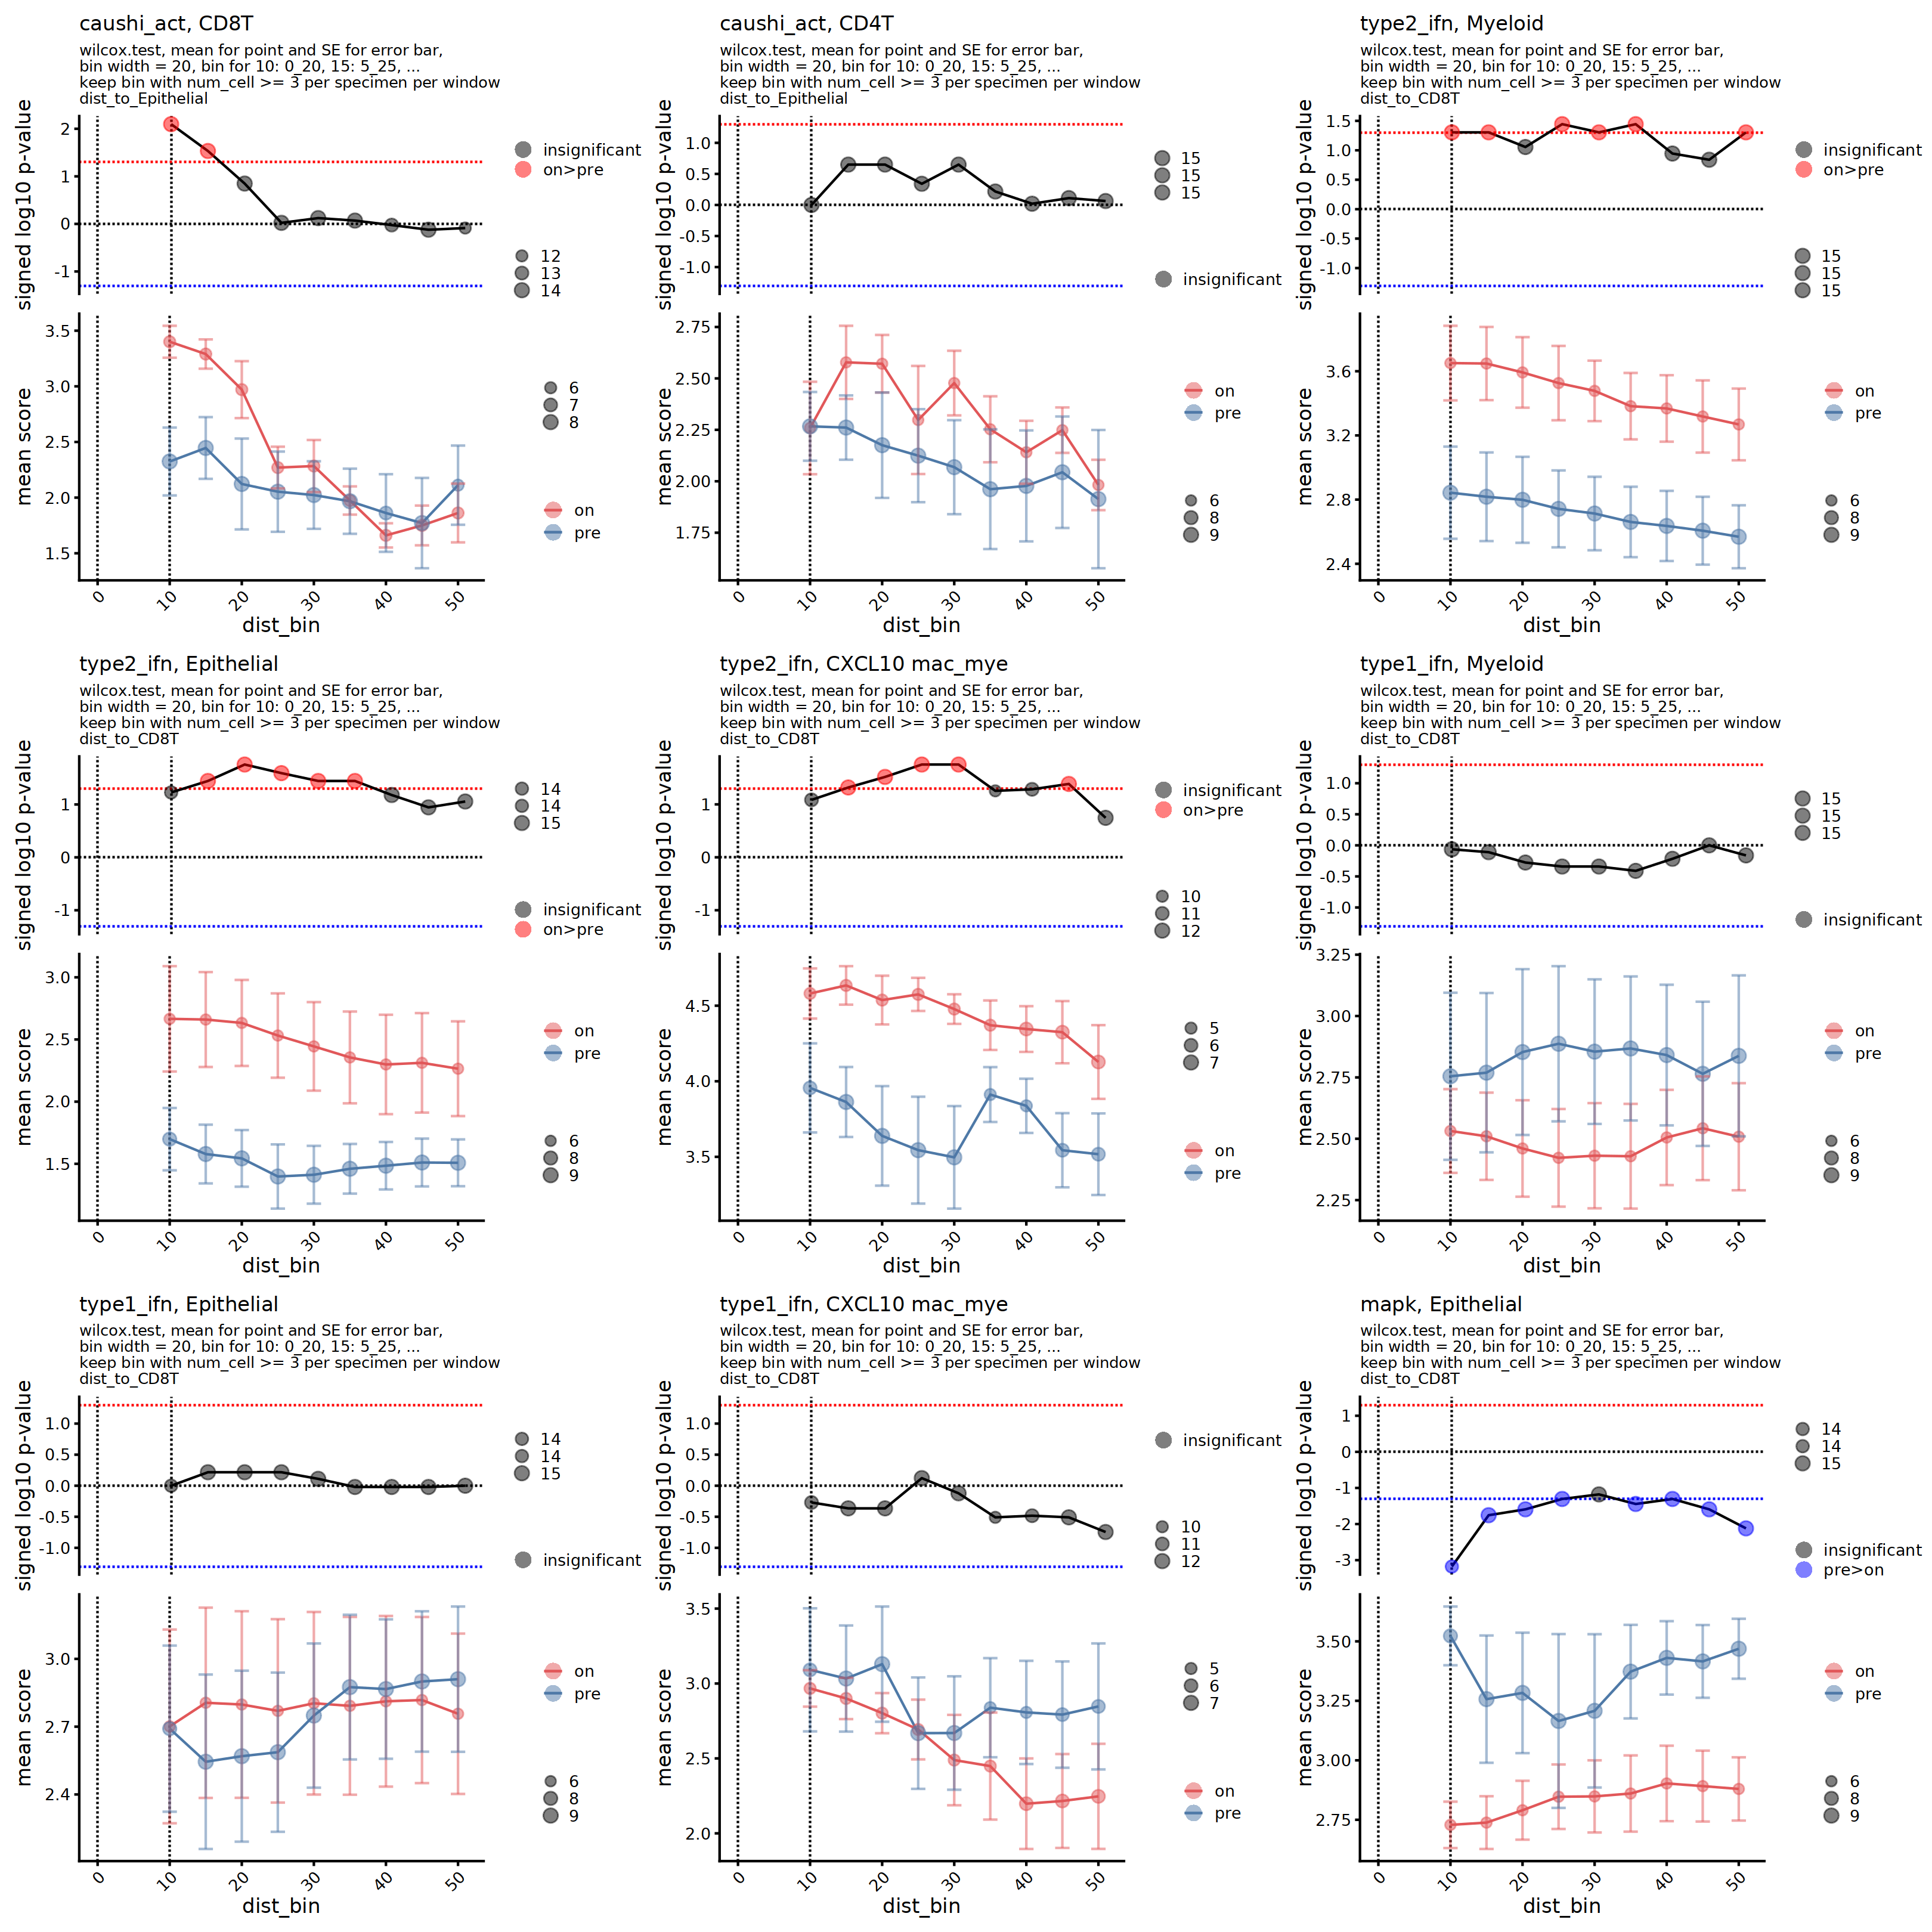

In [11]:
fig.size(27, 27)
p_score_50 <- res_list %>% purrr::map(function(res){res$plot}) %>% wrap_plots(ncol=3)
p_score_50

In [12]:
res_list %>% purrr::map(function(res){
    res$stat_df %>% 
            mutate(fdr=p.adjust(pvalue, method="fdr"), significant=if_else(fdr<0.1, "Yes", "No"))
})

dist_bin,celltype,score_name,dist_var,pvalue,signed_logpvalue,fc,num_sample,fdr,significant
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<chr>
10,CD8T,caushi_act,dist_to_Epithelial,0.007992008,2.09734409,1.4628865,14,0.07192807,Yes
15,CD8T,caushi_act,dist_to_Epithelial,0.029304029,1.53307266,1.3449814,14,0.13186813,No
20,CD8T,caushi_act,dist_to_Epithelial,0.141858142,0.84814573,1.3994564,14,0.42557443,No
25,CD8T,caushi_act,dist_to_Epithelial,0.949716950,0.02240581,1.1054971,14,0.94971695,No
30,CD8T,caushi_act,dist_to_Epithelial,0.754578755,0.12229543,1.1287386,14,0.94971695,No
35,CD8T,caushi_act,dist_to_Epithelial,0.851814852,0.06965479,1.0034163,14,0.94971695,No
40,CD8T,caushi_act,dist_to_Epithelial,0.945221445,-0.02446643,0.8919711,13,0.94971695,No
45,CD8T,caushi_act,dist_to_Epithelial,0.754578755,-0.12229543,0.9879889,14,0.94971695,No
50,CD8T,caushi_act,dist_to_Epithelial,0.818181818,-0.08715018,0.8816839,12,0.94971695,No


### Extract stats

In [13]:
res_list[["Epithelial_dist_to_CD8T_mapk"]]$stat_df %>% 
    mutate(p_median=signif(median(pvalue), 2), fc_median=signif(median(fc), 2))

dist_bin,celltype,score_name,dist_var,pvalue,signed_logpvalue,fc,num_sample,p_median,fc_median
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
10,Epithelial,mapk,dist_to_CD8T,0.0006660007,-3.176525,0.7745671,14,0.026,0.85
15,Epithelial,mapk,dist_to_CD8T,0.0175824176,-1.754921,0.8406955,15,0.026,0.85
20,Epithelial,mapk,dist_to_CD8T,0.0255744256,-1.592194,0.8498117,15,0.026,0.85
25,Epithelial,mapk,dist_to_CD8T,0.0495504496,-1.304952,0.8994379,15,0.026,0.85
30,Epithelial,mapk,dist_to_CD8T,0.0663336663,-1.178266,0.8879057,15,0.026,0.85
35,Epithelial,mapk,dist_to_CD8T,0.0359640360,-1.444132,0.8481376,15,0.026,0.85
40,Epithelial,mapk,dist_to_CD8T,0.0495504496,-1.304952,0.8461756,15,0.026,0.85
45,Epithelial,mapk,dist_to_CD8T,0.0255744256,-1.592194,0.8465541,15,0.026,0.85
50,Epithelial,mapk,dist_to_CD8T,0.0075924076,-2.119620,0.8301574,15,0.026,0.85


# Gene

## Function

In [ ]:
df_quasiPois_test <- function(
    df, formula_str="count ~ new_treatment + offset(log(countTotal))",
    effect_var="new_treatment", ref_level="pre"){
    df <- df %>% 
        mutate("{effect_var}" := as.factor(.data[[effect_var]])) %>% 
        mutate("{effect_var}" := relevel(.data[[effect_var]], ref = ref_level))
    effect_level <- unique(df[[effect_var]])
    effect_level <- effect_level[!(effect_level %in% ref_level)]
    effect_str <- paste0(effect_var, effect_level)
               
    mod_fit <- glm(formula = as.formula(formula_str), data = df, family = quasipoisson)
    pvalue <- summary(mod_fit)$coefficients[effect_str, "Pr(>|t|)"]
    effect_size <- summary(mod_fit)$coefficients[effect_str, "Estimate"]
    return(list(pvalue=pvalue, effect_size=effect_size, mod_fit=mod_fit))
}

compute_gene_stat_df <- function(exp_df){
    stat_df <- exp_df %>%
        group_by(gene, dist_bin, celltype, dist_var) %>%
        summarise({
            res <- df_quasiPois_test(df=pick(everything()))
            data.frame(pvalue=res$pvalue, effect_size=res$effect_size, num_sample=n())
        }, .groups="drop")
    stat_df
}

make_dist_gene_plot <- function(exp_df, stat_df, .dist_var, .celltype, .gene, plot_params) {
    list2env(plot_params, envir = environment())

    .stat <- stat_df %>%
        mutate(sig_type = case_when(
            pvalue < 0.05 & effect_size >=0 ~ "on>pre", 
            pvalue < 0.05 & effect_size <0 ~ "pre>on", 
            .default = "insignificant"
        ))
    p1 <- .stat %>%
        ggplot(aes(x = dist_bin, y = -log10(pvalue) * sign(effect_size))) +
            geom_vline(xintercept = 0, linetype = "dashed") +
            geom_vline(xintercept = bin_radius, linetype = "dashed") +
            geom_hline(yintercept = 0, linetype = "dashed") +
            geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "red") +
            geom_hline(yintercept = log10(0.05), linetype = "dashed", color = "blue") +
            geom_line() +
            geom_point(aes(color = sig_type, size = num_sample), alpha = .5) +
            scale_x_continuous(breaks = x_breaks) +
            scale_color_manual(values = pvalue_colvec) +
            scale_size_continuous(
                limits = c(min(.stat$num_sample) - 2, NA),
                breaks = c(min(.stat$num_sample),
                           round(mean(range(.stat$num_sample))),
                           max(.stat$num_sample))) +
            theme_classic(base_size = 20) +
            guides(color = guide_legend(override.aes = list(shape = 16, size = 7))) +
            labs(title    = paste0(.gene, ", ", .celltype),
                 subtitle = paste0(subtitle, "\n", .dist_var),
                 y="signed log10pvalue", size="", color="") +
            theme(axis.text.x   = element_text(angle = 45, hjust = 1),
                  plot.title    = element_text(size = 20),
                  plot.subtitle = element_text(size = 15))
    
    .exp_df <- exp_df %>% 
        filter(gene == .gene) %>% 
        filter(celltype == .celltype) %>% 
        group_by(new_treatment, dist_bin) %>% 
        summarise(
            mean=mean(log_exp), n_sample=n(), se=sd(log_exp)/sqrt(n_sample)) 
    
    p2 <- .exp_df %>%
        ggplot(aes(x = dist_bin, y = mean)) +
            geom_vline(xintercept = 0, linetype = "dashed") +
            geom_vline(xintercept = bin_radius, linetype = "dashed", color = "red") +
            geom_line(aes(color = new_treatment)) +
            geom_point(aes(color = new_treatment, size = n_sample), alpha = .5) +
            geom_errorbar(
                aes(ymin = mean-se, ymax = mean+se, color = new_treatment),
                width = 2, alpha = .5) +
            theme_classic(base_size = 20) +
            scale_x_continuous(breaks = x_breaks) +
            scale_color_manual(values = treatment_colvec) +
            scale_size_continuous(
                limits = c(min(.exp_df$n_sample) - 2, NA),
                breaks = c(min(.exp_df$n_sample),
                           round(mean(range(.exp_df$n_sample))),
                           max(.exp_df$n_sample))) +
            theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
            guides(color = guide_legend(override.aes = list(shape = 16, size = 7))) +
            labs(y = y_lab, size="", color="")

    (p1 / p2) + plot_layout(axes = "collect", heights = c(2, 3))
}

analyze_dist_gene <- function(.celltype_var, .celltype, .dist_var, .gene,
                              cell_meta, counts, sample_meta, bin_df,
                              num_cell_cutoff, plot_params) {
    exp_df <- compute_exp_df(
        .celltype_var, .celltype, .dist_var, cell_meta, counts, sample_meta,
        bin_df, num_cell_cutoff)
    exp_df <- exp_df %>% filter(gene==.gene)
    stat_df <- compute_gene_stat_df(exp_df)
    plot <- make_dist_gene_plot(exp_df, stat_df, .dist_var, .celltype, .gene, plot_params)
    
    list(exp_df = exp_df, stat_df = stat_df, plot = plot)
}

## Plot

In [15]:
# --- Data setup ---
x_breaks   <- seq(0, 100, 10)
bin_radius <- 10
bin_vec    <- seq(10, 50, 5)
bin_list   <- bin_vec %>% purrr::map(function(x) c(x - bin_radius, x + bin_radius, x))
bin_df     <- data.frame(dist_bin=bin_vec, dist_min=bin_vec-bin_radius, dist_max=bin_vec+bin_radius)
bin_info   <- paste0(
    "bin width = ", bin_radius * 2, ", ",
    "bin for ",
    paste0(bin_list[[1]][3], ": ", bin_list[[1]][1], "_", bin_list[[1]][2]), ", ",
    paste0(bin_list[[2]][3], ": ", bin_list[[2]][1], "_", bin_list[[2]][2]), ", ..."
)

num_cell_cutoff <- 3
qc_cell_meta    <- cell_meta %>% filter(new_specimenID != "xe_Pt21pre")

plot_params <- list(
    x_breaks         = x_breaks,
    bin_radius       = bin_radius,
    pvalue_colvec    = c("on>pre" = "red", "pre>on" = "blue", "insignificant" = "black"),
    treatment_colvec = c("on" = "#E15759", "pre" = "#4E79A7"),
    y_lab            = "mean expression",
    subtitle         = paste0(
        "wilcox.test, mean for point and SE for error bar, \n",
        bin_info, "\n",
        "keep bin with num_cell >= ", num_cell_cutoff, " per specimen per window"
    )
)

In [16]:
res <- analyze_dist_gene(
    .celltype_var="celltype_lvl_2", .celltype="CD8T",
    .dist_var="dist_to_Epithelial", .gene="IFNG", cell_meta=qc_cell_meta,
    counts=counts, sample_meta=sample_meta, bin_df=bin_df,
    num_cell_cutoff=num_cell_cutoff, plot_params=plot_params
)

Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(new_speci

gene,dist_bin,celltype,dist_var,pvalue,effect_size,num_sample,fdr,significant
<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<chr>
IFNG,10,CD8T,dist_to_Epithelial,0.04529296,0.9627494,14,0.1358789,No
IFNG,15,CD8T,dist_to_Epithelial,0.02120779,0.9711942,14,0.1107374,No
IFNG,20,CD8T,dist_to_Epithelial,0.02460831,1.1570400,14,0.1107374,No
IFNG,25,CD8T,dist_to_Epithelial,0.09017063,0.9399386,14,0.2028839,No
IFNG,30,CD8T,dist_to_Epithelial,0.11474004,0.8470997,14,0.2065321,No
IFNG,35,CD8T,dist_to_Epithelial,0.62260520,0.3481245,14,0.6226052,No
IFNG,40,CD8T,dist_to_Epithelial,0.21524588,-1.1893534,13,0.3228688,No
IFNG,45,CD8T,dist_to_Epithelial,0.25118211,-1.6035077,14,0.3229484,No
IFNG,50,CD8T,dist_to_Epithelial,0.30517899,-0.9507787,12,0.3433264,No


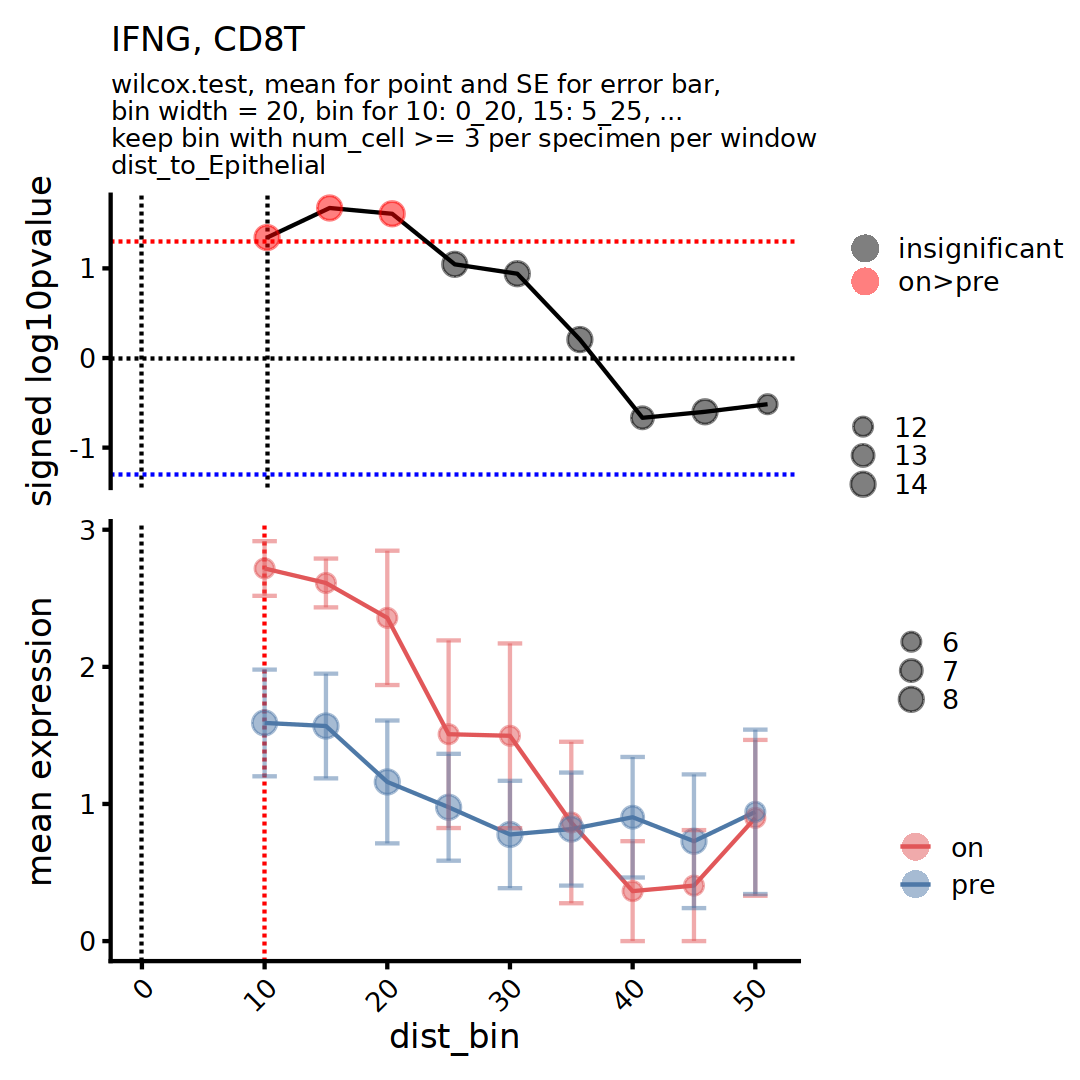

In [17]:
p_infg_50 <- res$plot
res$stat_df %>% 
    mutate(fdr=p.adjust(pvalue, method="fdr"), significant=if_else(fdr<0.1, "Yes", "No"))

fig.size(9, 9)
p_infg_50

# Regression

In [25]:
plot_score_sample <- function(df, title){
    plt <- df %>% 
        ggplot(aes(x=dist_bin, y=score_value, color=new_specimenID)) +
            geom_line() +
            geom_point(aes(size = countTotal)) +
            scale_color_tableau("Tableau 20") +
            theme_classic(base_size=20) +
            labs(title=title, y="score", color="", size="") +
            NULL
    return(plt)
}

In [26]:
# Make combined patchwork plot for one (celltype, dist_var, score)
# plot_params: list(x_breaks, bin_radius, pvalue_colvec, treatment_colvec, y_lab, subtitle)
ind_dist_score_plot <- function(score_df, .dist_var, .celltype, .score_name, plot_params) {
    list2env(plot_params, envir = environment())
    
    .score <- score_df %>%
        group_by(dist_bin, new_treatment) %>%
        summarise(mean = mean(score_value), n_sample = n(),
                  se = sd(score_value) / sqrt(n_sample), .groups = "drop")
    p <- .score %>%
        ggplot(aes(x = dist_bin, y = mean)) +
            geom_vline(xintercept = 0, linetype = "dashed") +
            geom_vline(xintercept = bin_radius, linetype = "dashed") +
            geom_line(aes(color = new_treatment)) +
            geom_point(aes(color = new_treatment, size = n_sample), alpha = .5) +
            geom_errorbar(
                aes(ymin = mean-se, ymax = mean+se, color = new_treatment),
                width = 2, alpha = .5) +
            theme_classic(base_size = 20) +
            scale_x_continuous(breaks = x_breaks) +
            scale_color_manual(values = treatment_colvec) +
            scale_size_continuous(
                limits = c(min(.score$n_sample) - 2, NA),
                breaks = c(min(.score$n_sample),
                           round(mean(range(.score$n_sample))),
                           max(.score$n_sample))) +
            theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
            guides(color = guide_legend(override.aes = list(shape = 16, size = 7))) +
            labs(y=y_lab, size="", color="",
                 title=paste0(.score_name, ", ", .celltype),
                 subtitle = paste0(subtitle, "\n", .dist_var))
    p
}


In [ ]:
# --- Data setup ---
caushi_act <- c("CXCL13", "ENTPD1", "IFNG", "GZMA")
type1_ifn  <- c("IFI27", "IFI6", "IFITM1", "IFIT1", "MX1", "ISG15", "ISG20")
type2_ifn  <- c(
    "IDO1","CXCL9","CXCL10","CXCL11","HLA-DRA","HLA-DRB1","PSMB8","PSMB9",
    "STAT1","GBP4","GBP1","GBP5")
mapk <- c(
    'PHLDA1', 'SPRY2', 'SPRY4', 'ETV4', 'ETV5', 'DUSP4', 'DUSP6', 'CCND1',
    'EPHA2', 'EPHA4')
defined_score_list <- list(
    caushi_act=caushi_act, type1_ifn=type1_ifn, type2_ifn=type2_ifn, mapk=mapk)

score_list <- defined_score_list %>%
    purrr::map(function(.score) .score[.score %in% row.names(counts)])


x_breaks   <- seq(0, 100, 10)
bin_radius <- 10
bin_vec    <- seq(10, 100, 5)
bin_list   <- bin_vec %>% purrr::map(function(x) c(x - bin_radius, x + bin_radius, x))
bin_df     <- data.frame(dist_bin=bin_vec, dist_min=bin_vec-bin_radius, dist_max=bin_vec+bin_radius)
bin_info   <- paste0(
    "bin width = ", bin_radius * 2, ", ",
    "bin for ",
    paste0(bin_list[[1]][3], ": ", bin_list[[1]][1], "_", bin_list[[1]][2]), ", ",
    paste0(bin_list[[2]][3], ": ", bin_list[[2]][1], "_", bin_list[[2]][2]), ", ..."
)

num_cell_cutoff <- 3
qc_cell_meta    <- cell_meta %>% filter(new_specimenID != "xe_Pt21pre")

plot_params <- list(
    x_breaks         = x_breaks,
    bin_radius       = bin_radius,
    pvalue_colvec    = c("on>pre" = "red", "pre>on" = "blue", "insignificant" = "black"),
    treatment_colvec = c("on" = "#E15759", "pre" = "#4E79A7"),
    y_lab            = "mean of lognorm exp",
    subtitle         = paste0(
        "wilcox.test, mean for point and SE for error bar, \n",
        bin_info, "\n",
        "keep bin with num_cell >= ", num_cell_cutoff, " per specimen per window"
    )
)

In [28]:
params_df <- data.frame(
  celltype_var = c(
      "celltype_lvl_2", "celltype_lvl_2", "celltype_level_1",
      "celltype_level_1","celltype_finest_lvl", "celltype_level_1",
      "celltype_level_1", "celltype_finest_lvl", "celltype_level_1"),
  celltype = c(
      "CD8T", "CD4T", "Myeloid", "Epithelial", "CXCL10 mac_mye", "Myeloid",
      "Epithelial", "CXCL10 mac_mye", "Epithelial"),
  dist_var= c(
      "dist_to_Epithelial", "dist_to_Epithelial", "dist_to_CD8T", "dist_to_CD8T",
      "dist_to_CD8T", "dist_to_CD8T", "dist_to_CD8T", "dist_to_CD8T", "dist_to_CD8T"),
  score_name = c(
      "caushi_act", "caushi_act", "type2_ifn", "type2_ifn", "type2_ifn",
      "type1_ifn", "type1_ifn", "type1_ifn", "mapk"),
  stringsAsFactors = FALSE
)


res_list <- purrr::pmap(params_df, function(celltype_var, celltype, dist_var, score_name){
    res <- analyze_dist_score(
        celltype_var, celltype, dist_var, score_name, qc_cell_meta, counts,
        sample_meta, bin_df, num_cell_cutoff, score_list, plot_params)
    .df <- res$score_df %>% 
        filter(new_treatment=="on")
    res$mod_fit <- lmerTest::lmer(
        formula = score_value ~ dist_bin + (1+ dist_bin|new_specimenID), data = .df)
    res$mod_df <- summary(res$mod_fit)$coefficients
    res$cor_res <- rmcorr(participant=new_specimenID, measure1=dist_bin, measure2=score_value, dataset=.df) 
    .title <- paste0(celltype, "_", dist_var, "_", score_name)
    res$p_sample <- plot_score_sample(.df, .title)
    res$p_on <- ind_dist_score_plot(
        .df, .dist_var=dist_var, .celltype=celltype, .score_name=score_name,
        plot_params=plot_params)
    res
})
names(res_list) <- paste0(params_df$celltype, "_", params_df$dist_var, "_", params_df$score_name)

Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(gene, new_specimenID)`
Joining with `by = join_by(new_speci

,Estimate,Std. Error,df,t value,Pr(>|t|)
(Intercept),3.756958226,0.234789307,5.272222,16.001403,1.135021e-05
dist_bin,-0.009704197,0.002446008,5.099252,-3.967362,1.025272e-02


[1] "rmcorr=-0.801846151122487"


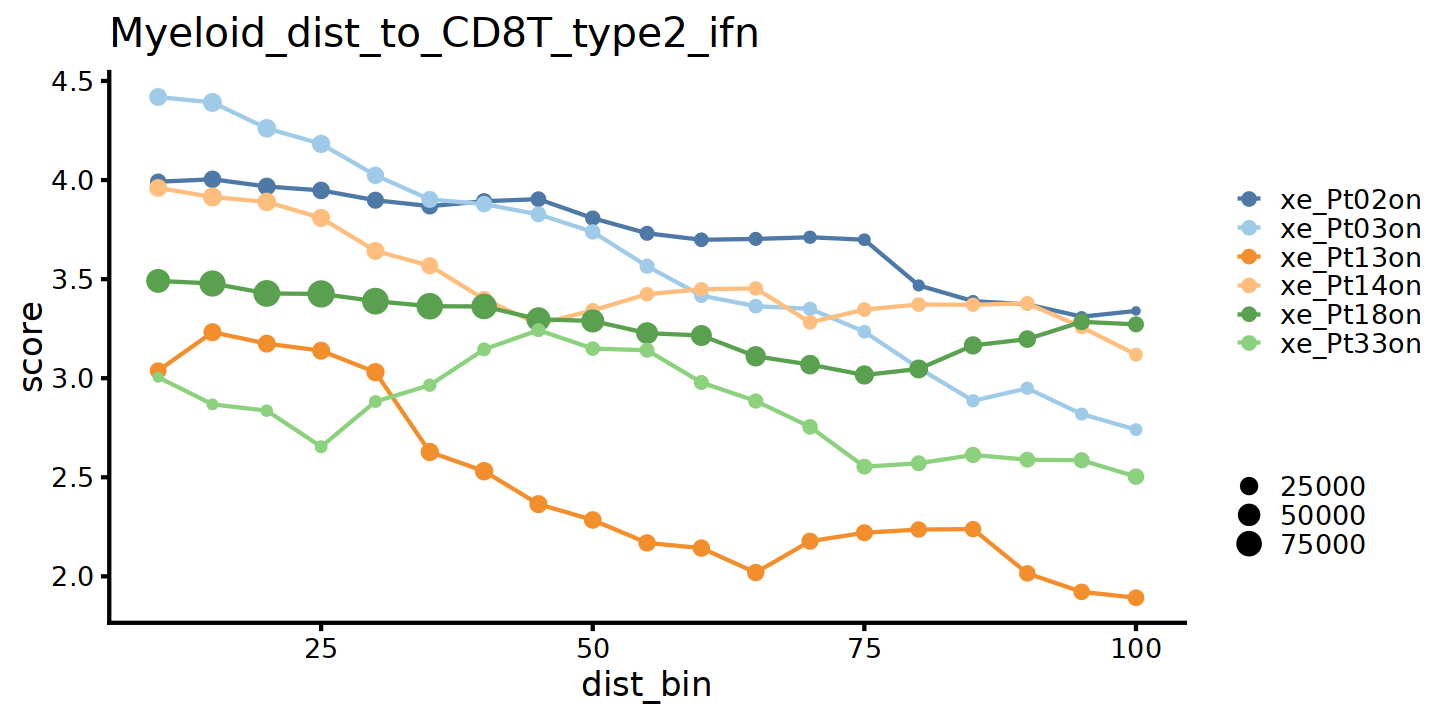

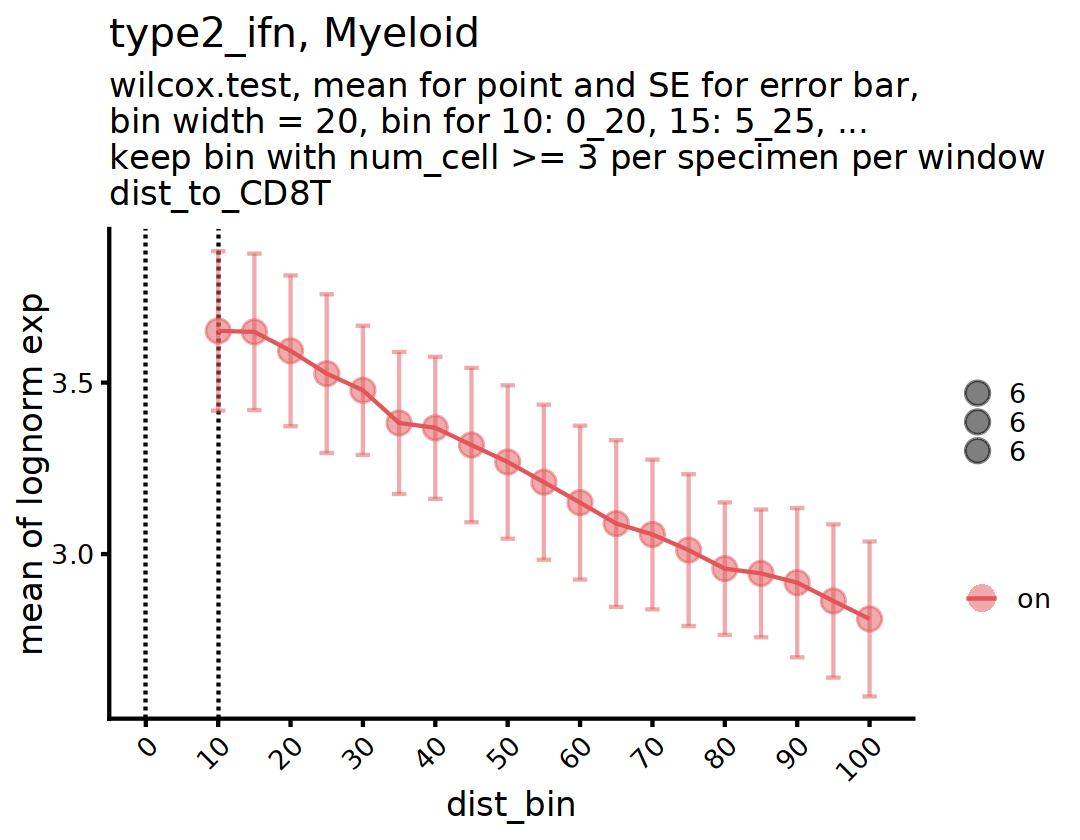

In [31]:
.dist_var<-"dist_to_CD8T"
.celltype<-"Myeloid"
.score_name<-"type2_ifn"
.target <- paste0(.celltype, "_", .dist_var, "_", .score_name)

res_list[[.target]]$mod_df
print(paste0("rmcorr=", res_list[[.target]]$cor_res$r))
fig.size(6, 12)
res_list[[.target]]$p_sample
fig.size(7, 9)
res_list[[.target]]$p_on

,Estimate,Std. Error,df,t value,Pr(>|t|)
(Intercept),2.720364876,0.399473445,5.005096,6.809877,0.001036105
dist_bin,-0.008513743,0.002123103,5.002285,-4.010048,0.010211550


[1] "rmcorr=-0.762509910077966"


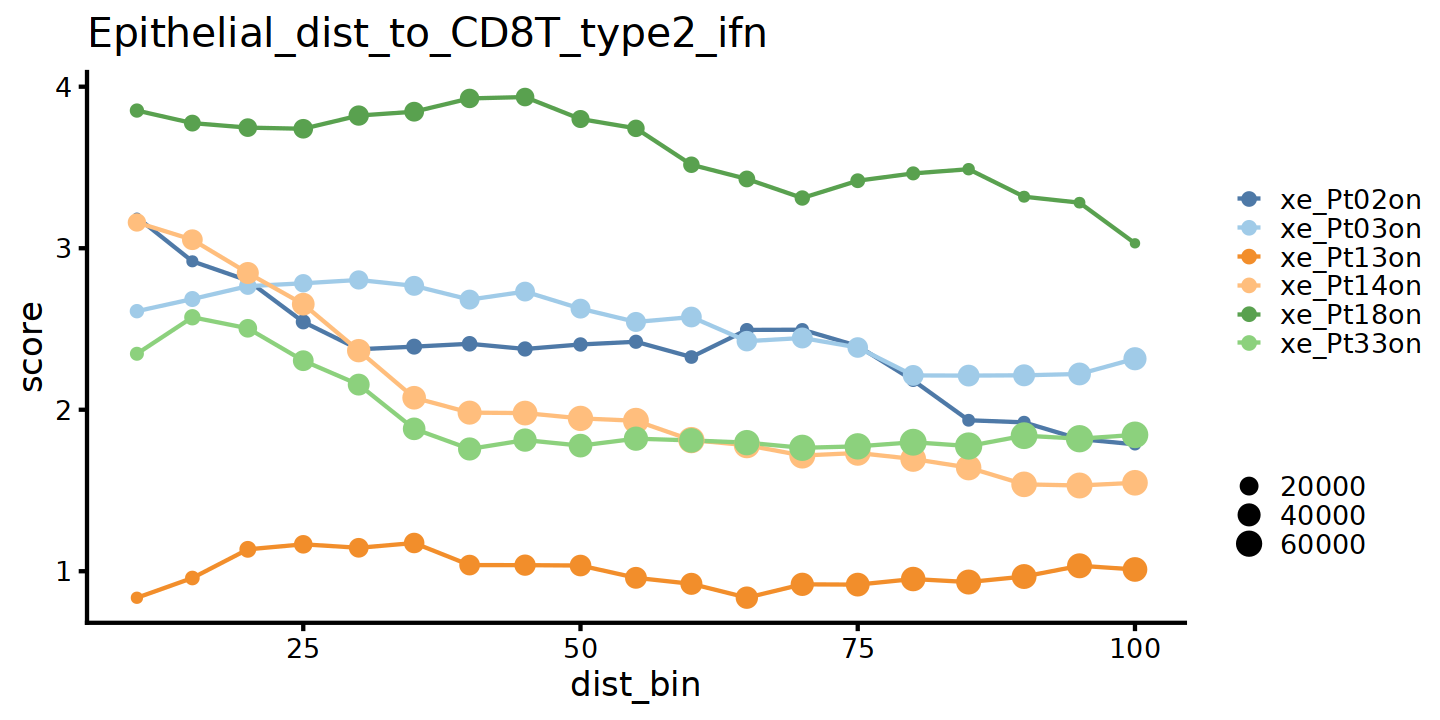

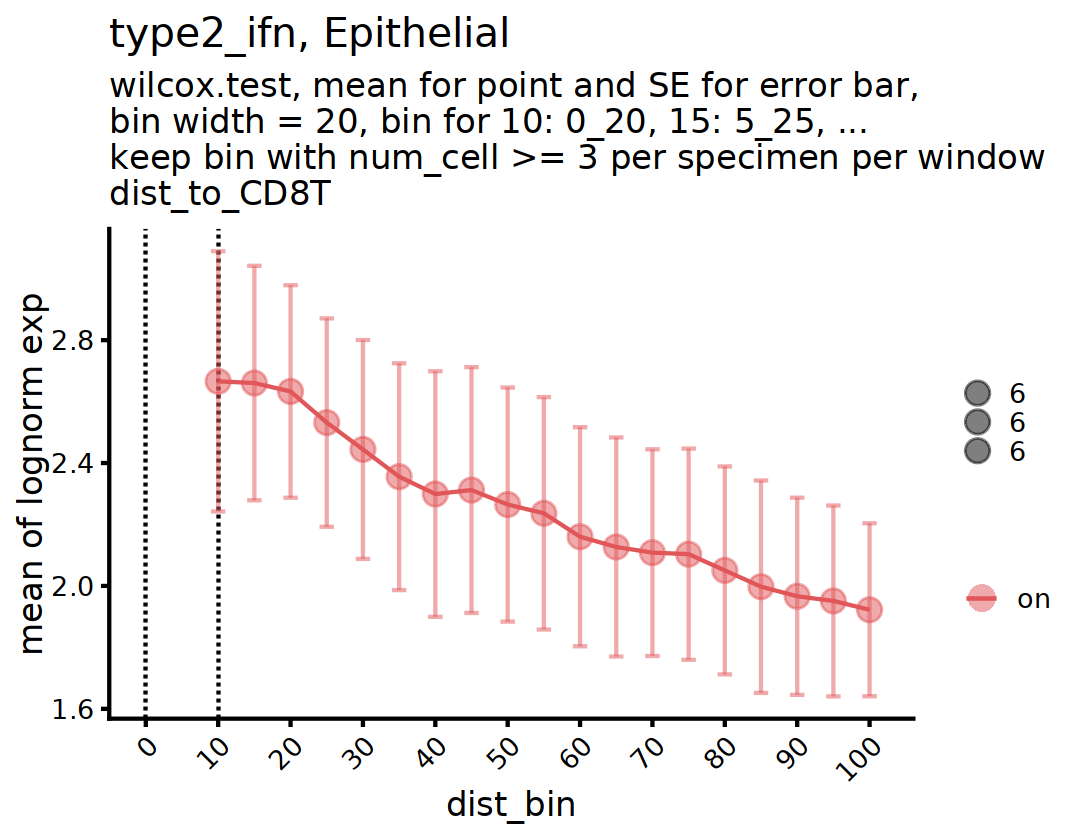

In [32]:
.dist_var<-"dist_to_CD8T"
.celltype<-"Epithelial"
.score_name<-"type2_ifn"
.target <- paste0(.celltype, "_", .dist_var, "_", .score_name)

res_list[[.target]]$mod_df
print(paste0("rmcorr=", res_list[[.target]]$cor_res$r))
fig.size(6, 12)
res_list[[.target]]$p_sample
fig.size(7, 9)
res_list[[.target]]$p_on

,Estimate,Std. Error,df,t value,Pr(>|t|)
(Intercept),4.76930042,0.131480278,4.319312,36.273884,1.558203e-06
dist_bin,-0.01172897,0.003486525,4.669454,-3.364085,2.223543e-02


[1] "rmcorr=-0.647013140717395"


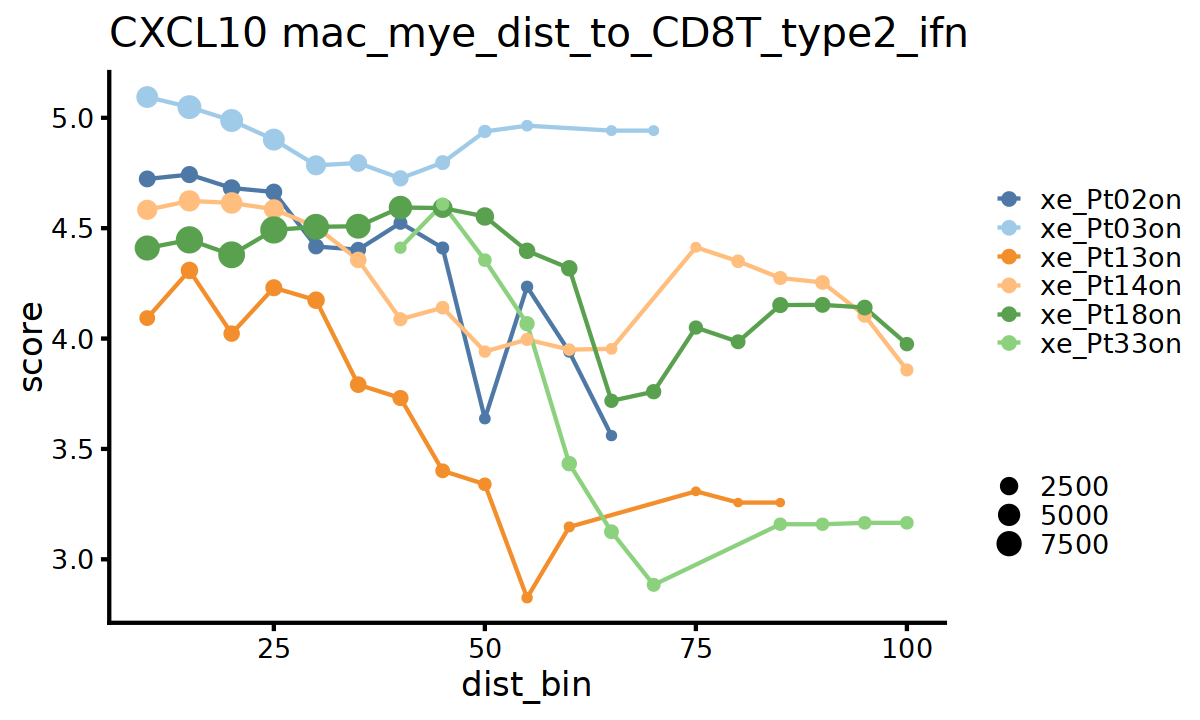

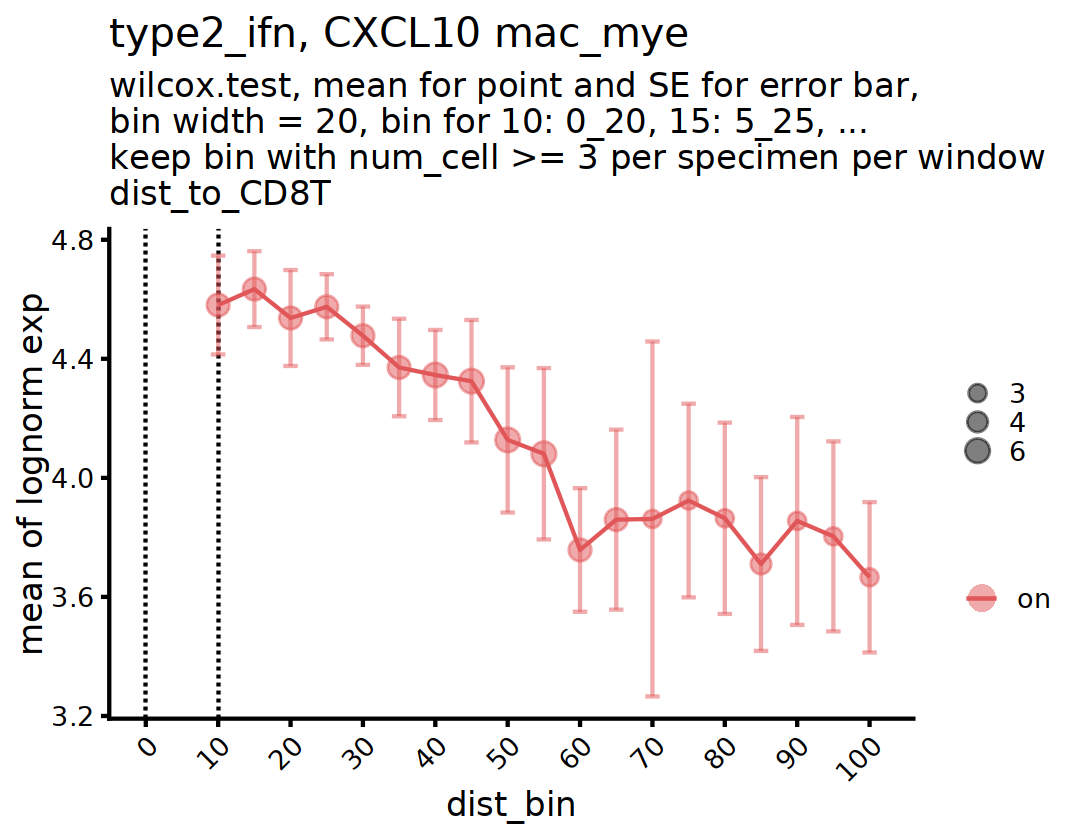

In [33]:
.dist_var<-"dist_to_CD8T"
.celltype<-"CXCL10 mac_mye"
.score_name<-"type2_ifn"
.target <- paste0(.celltype, "_", .dist_var, "_", .score_name)

res_list[[.target]]$mod_df
print(paste0("rmcorr=", res_list[[.target]]$cor_res$r))
fig.size(6, 10)
res_list[[.target]]$p_sample
fig.size(7, 9)
res_list[[.target]]$p_on

In [34]:
sessionInfo()

R version 4.1.2 (2021-11-01)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Red Hat Enterprise Linux 9.7 (Plow)

Matrix products: default
BLAS/LAPACK: /home/hoy821/miniforge3/lib/libopenblasp-r0.3.24.so

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] SeuratObject_4.1.4      sp_2.2-0                rmcorr_0.7.0           
 [4] FNN_1.1.4.1             lme4_1.1-33             Matrix_1.6-1.1         
 [7] singlecellmethods_0.1.0 data.table_1.18.0       ggpubr_0.6.0           
[10] patchwork_1.3.2         ggthemes_4.2.4          ggplot2_4.0.1  